In [ ]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV

df = pd.read_csv("passenger_satisfaction_cleaned.csv")

FEATURES = [
    "flight_distance", "departure_delay_in_minutes", "arrival_delay_in_minutes",
    "seat_comfort", "inflight_wifi_service", "food_and_drink", "inflight_entertainment",
    "ease_of_online_booking", "online_boarding", "online_support",
    "age", "gender", "customer_type", "class"
]
TARGET = "satisfaction"

df = df[FEATURES + [TARGET]].dropna()

In [ ]:
le_gender = LabelEncoder()
le_customer = LabelEncoder()
le_class = LabelEncoder()

df["gender"] = le_gender.fit_transform(df["gender"])
df["customer_type"] = le_customer.fit_transform(df["customer_type"])
df["class"] = le_class.fit_transform(df["class"])

X = df[FEATURES].values
y = df[TARGET].values

In [ ]:
minority_count = int(np.sum(y == 0))
k_nn = max(1, min(minority_count - 1, 5))

if minority_count > 1:
    smote = SMOTE(k_neighbors=k_nn, random_state=42)
    X_res, y_res = smote.fit_resample(X, y)
else:
    X_res, y_res = X, y

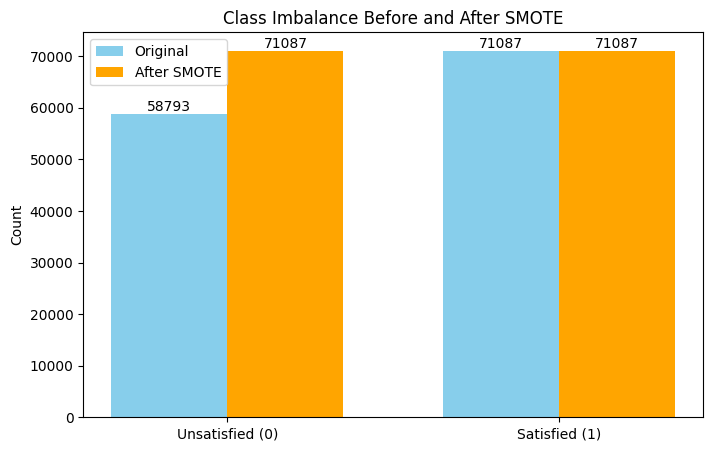

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

original_counts = np.bincount(y)
resampled_counts = np.bincount(y_res)

classes = ["Unsatisfied (0)", "Satisfied (1)"]
x = np.arange(len(classes))

width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - width/2, original_counts, width, label="Original", color="skyblue")

ax.bar(x + width/2, resampled_counts, width, label="After SMOTE", color="orange")

ax.set_ylabel("Count")
ax.set_title("Class Imbalance Before and After SMOTE")
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

for i, (orig, res) in enumerate(zip(original_counts, resampled_counts)):
    ax.text(i - width/2, orig + 2, str(orig), ha='center', va='bottom')
    ax.text(i + width/2, res + 2, str(res), ha='center', va='bottom')

plt.show()

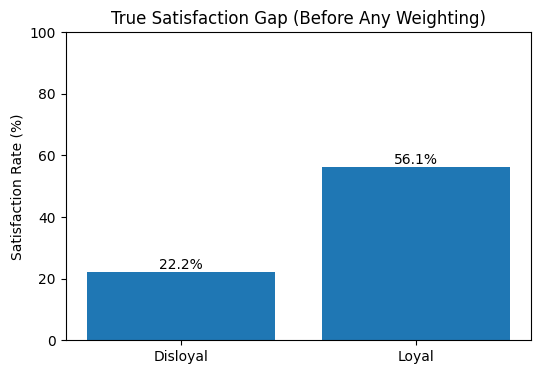

In [ ]:
df_res = pd.DataFrame(X_res, columns=FEATURES)
df_res[TARGET] = y_res

disloyal_code = le_customer.transform(["disloyal Customer"])[0]

df_res["loyalty_group"] = df_res["customer_type"].apply(
    lambda x: "Disloyal" if x == disloyal_code else "Loyal"
)

group_means = df_res.groupby("loyalty_group")[TARGET].mean() * 100

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(group_means.index, group_means.values)

plt.title("True Satisfaction Gap (Before Any Weighting)")
plt.ylabel("Satisfaction Rate (%)")

for i, v in enumerate(group_means.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.ylim(0, 100)
plt.show()

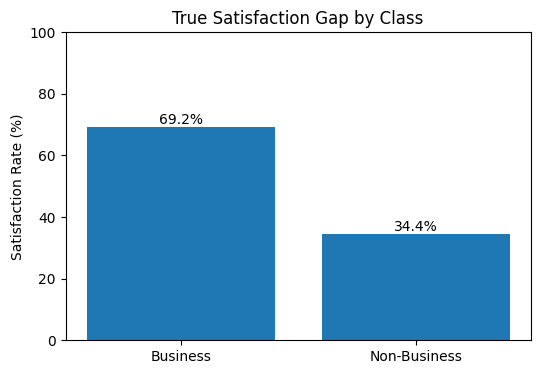

In [ ]:
business_code = le_class.transform(["Business"])[0]

df_res["group"] = df_res["class"].apply(
    lambda x: "Business" if x == business_code else "Non-Business"
)
class_means = df_res.groupby("group")[TARGET].mean() * 100

plt.figure(figsize=(6,4))
plt.bar(class_means.index, class_means.values)

plt.title("True Satisfaction Gap by Class")
plt.ylabel("Satisfaction Rate (%)")

for i, v in enumerate(class_means.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.ylim(0, 100)
plt.show()

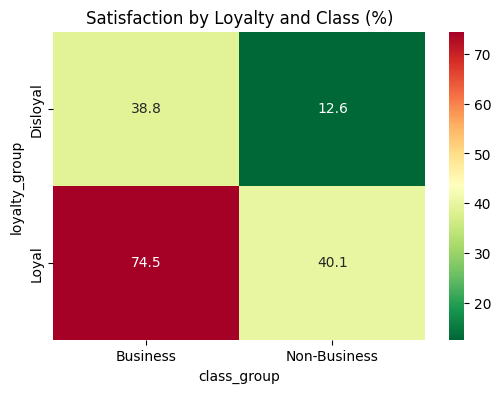

In [ ]:
import seaborn as sns

df_res["class_group"] = df_res["class"].apply(
    lambda x: "Business" if x == business_code else "Non-Business"
)

heatmap_data = df_res.pivot_table(
    index="loyalty_group",
    columns="class_group",
    values=TARGET,
    aggfunc="mean"
) * 100

plt.figure(figsize=(6,4))
sns.heatmap(heatmap_data, annot=True, cmap="RdYlGn_r", fmt=".1f")

plt.title("Satisfaction by Loyalty and Class (%)")
plt.show()

In [ ]:
df_res = pd.DataFrame(X_res, columns=FEATURES)
df_res[TARGET] = y_res

weights = np.ones(len(df_res))

disloyal_code = le_customer.transform(["disloyal Customer"])[0]
business_code = le_class.transform(["Business"])[0]

is_disloyal = df_res["customer_type"] == disloyal_code
is_non_business = df_res["class"] != business_code

both_risk = is_disloyal & is_non_business
weights[both_risk] *= 1.8

weights[is_disloyal & ~is_non_business] *= 1.4

weights[~is_disloyal & is_non_business] *= 1.3

In [ ]:
X_train, X_test, y_train, y_test, sw_train, sw_test = train_test_split(
    X_res, y_res, weights,
    test_size=0.2, random_state=42, stratify=y_res
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [ ]:
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.base import BaseEstimator, ClassifierMixin

class WeightedLDA(BaseEstimator, ClassifierMixin):
    """LDA wrapper that approximates sample weights by duplicating rows so it can take in sample weights"""
    def __init__(self, solver="svd", shrinkage=None):
        self.solver = solver
        self.shrinkage = shrinkage

    def fit(self, X, y, sample_weight=None):
        if sample_weight is not None:
            # Scale weights to integer counts (min 1), then repeat rows
            w = sample_weight / sample_weight.min()
            counts = np.round(w).astype(int).clip(min=1)
            X = np.repeat(X, counts, axis=0)
            y = np.repeat(y, counts, axis=0)
        self.model_ = LinearDiscriminantAnalysis(
            solver=self.solver,
            shrinkage=self.shrinkage
        )
        self.model_.fit(X, y)
        self.classes_ = self.model_.classes_
        return self

    def predict(self, X):
        return self.model_.predict(X)

    def predict_proba(self, X):
        return self.model_.predict_proba(X)

    def score(self, X, y):
        return self.model_.score(X, y)

models = {
    "Hist Gradient Boosting": HistGradientBoostingClassifier(),
    "Neural Network (MLP)": MLPClassifier(max_iter=500),
    "LDA": WeightedLDA()
}
param_grids = {
    "Hist Gradient Boosting": {
        "max_depth": [3, 5, 7],
        "max_iter": [100, 200, 300],
        "learning_rate": [0.05, 0.1, 0.2]
    },
    "Neural Network (MLP)": {
        "hidden_layer_sizes": [(50,), (100,), (100, 50)],
        "alpha": [0.0001, 0.001, 0.01]
    },
    "LDA": {
        "solver": ["lsqr", "eigen"],  # svd doesn't support shrinkage, excluded
        "shrinkage": [None, "auto", 0.1, 0.5, 0.9]
    }
}

best_models = {}
for name, model in models.items():
    search = RandomizedSearchCV(
        model,
        param_distributions=param_grids[name],
        n_iter=10,
        scoring="f1",
        cv=3,
        n_jobs=-1,
        random_state=42
    )
    search.fit(X_train_sc, y_train, sample_weight=sw_train)
    best_models[name] = search.best_estimator_
    print(f"{name} best params:", search.best_params_)

Hist Gradient Boosting best params: {'max_iter': 300, 'max_depth': 7, 'learning_rate': 0.1}
Neural Network (MLP) best params: {'hidden_layer_sizes': (100, 50), 'alpha': 0.001}
LDA best params: {'solver': 'lsqr', 'shrinkage': None}


In [ ]:

def evaluate(name, model):

    if name == "LDA":
        model.fit(X_train_sc, y_train, sample_weight=sw_train)
    else:
        model.fit(X_train_sc, y_train, sample_weight=sw_train)

    y_pred = model.predict(X_test_sc)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_sc)[:, 1]
    else:
        y_prob = model.decision_function(X_test_sc)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)

    return {
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc,
        "specificity": spec,
        "model_obj": model,
        "cm": cm,
        "prob": y_prob
    }

results = [
    evaluate(name, model)
    for name, model in best_models.items()
]

In [ ]:

print("\nMODEL PERFORMANCE\n" + "-"*60)

for r in results:
    print(f"\n{r['model']}")
    print(f"Accuracy:    {r['accuracy']:.4f}")
    print(f"Precision:   {r['precision']:.4f}")
    print(f"Recall:      {r['recall']:.4f}")
    print(f"F1 Score:    {r['f1']:.4f}")
    print(f"ROC AUC:     {r['auc']:.4f}")
    print(f"Specificity: {r['specificity']:.4f}")


MODEL PERFORMANCE
------------------------------------------------------------

Hist Gradient Boosting
Accuracy:    0.9389
Precision:   0.9384
Recall:      0.9394
F1 Score:    0.9389
ROC AUC:     0.9875
Specificity: 0.9384

Neural Network (MLP)
Accuracy:    0.9342
Precision:   0.9371
Recall:      0.9309
F1 Score:    0.9340
ROC AUC:     0.9854
Specificity: 0.9375

LDA
Accuracy:    0.8260
Precision:   0.8220
Recall:      0.8322
F1 Score:    0.8271
ROC AUC:     0.8947
Specificity: 0.8198


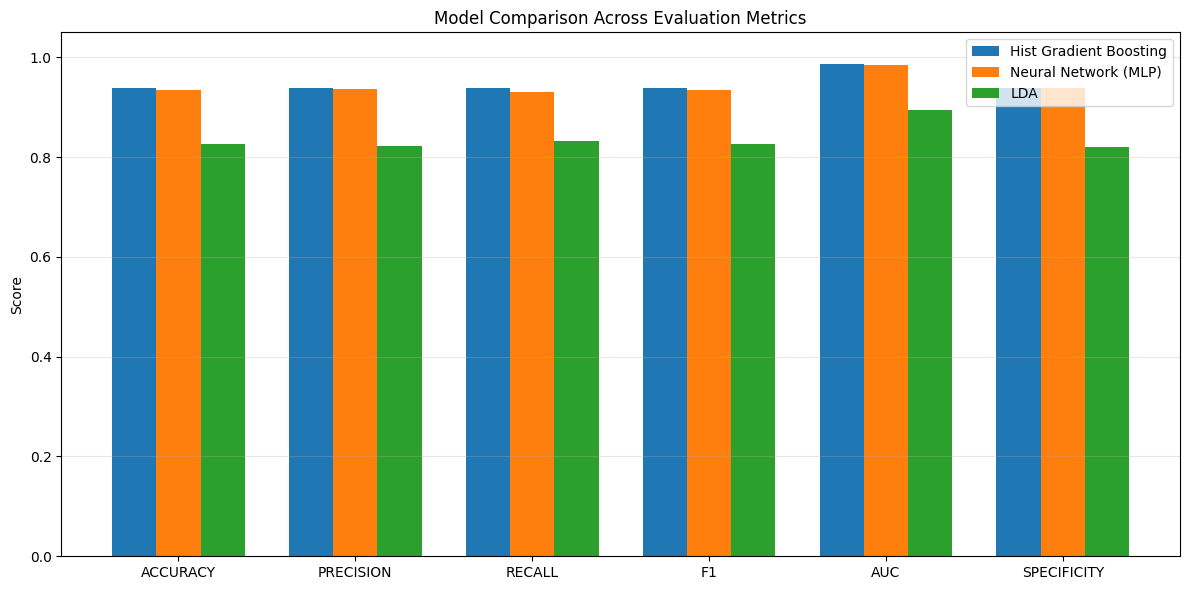

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

metric_cols = ["accuracy", "precision", "recall", "f1", "auc", "specificity"]

models = [r["model"] for r in results]

values = np.array([
    [r[m] for m in metric_cols]
    for r in results
])

x = np.arange(len(metric_cols))
width = 0.25

plt.figure(figsize=(12, 6))

for i, model in enumerate(models):
    plt.bar(
        x + i * width,
        values[i],
        width,
        label=model
    )

plt.xticks(
    x + width,
    [m.upper() for m in metric_cols]
)

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Model Comparison Across Evaluation Metrics")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

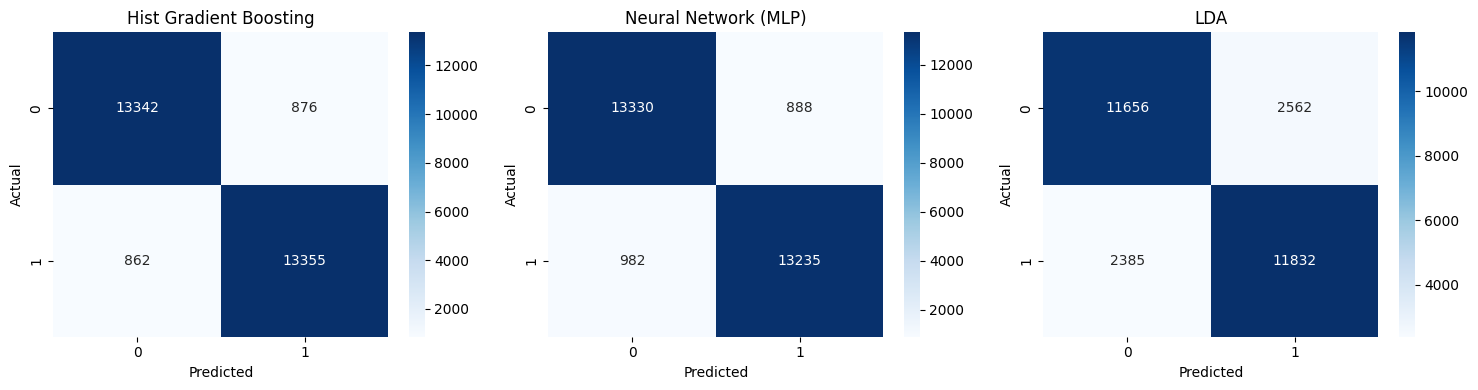

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, r in zip(axes, results):
    sns.heatmap(r["cm"], annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(r["model"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

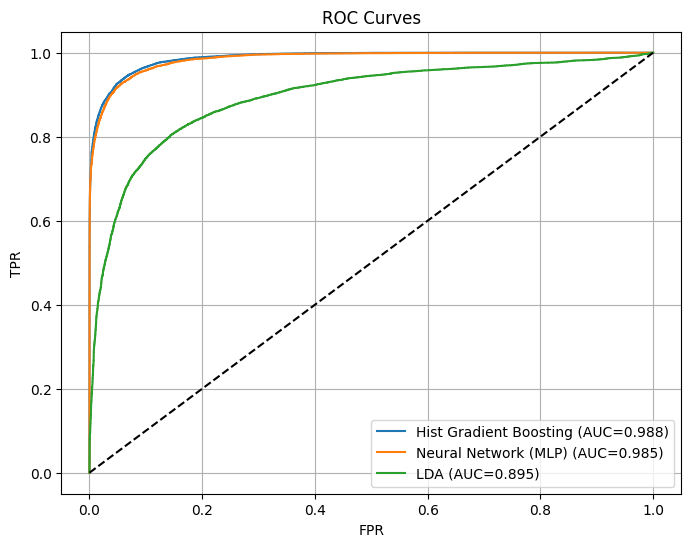

In [ ]:
plt.figure(figsize=(8, 6))

for r in results:
    fpr, tpr, _ = roc_curve(y_test, r["prob"])
    plt.plot(fpr, tpr, label=f"{r['model']} (AUC={r['auc']:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.legend()
plt.title("ROC Curves")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.grid()
plt.show()